In [ ]:
!pip install ucimlrepo

In [ ]:
import warnings
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder
import pandas as pd
warnings.filterwarnings("ignore")

# fetch dataset
nursery = pd.read_csv('/content/nursery.csv')

In [ ]:
nursery

,parents,has_nurs,form,children,housing,finance,social,health,final evaluation
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority
...,...,...,...,...,...,...,...,...,...
12955,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,priority,spec_prior
12956,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,not_recom,not_recom
12957,great_pret,very_crit,foster,more,critical,inconv,problematic,recommended,spec_prior
12958,great_pret,very_crit,foster,more,critical,inconv,problematic,priority,spec_prior


In [ ]:
L = len(nursery.index)
def print_counts(df):
    for x in df.columns:
        for i, y in zip(df[x].value_counts().index, df[x].value_counts()):
            i = str(i)
            s = f'{i:14}{y/L:4.2f} {y:4d}'
            print(s)
        print('\n')
for x in nursery.drop(['health', 'final evaluation'], axis=1).columns:
    lst = list(nursery[x].value_counts().index)
    dic = {k:i+1 for i, k in enumerate(lst)}
    nursery[x].replace(dic, inplace=True)

print_counts(nursery)

dic1 = {'recommended': 2,
        'priority': 3,
        'not_recom': 1}


dic2 = {'not_recom':1,
        'priority':4,
        'spec_prior':5,
        'very_recom':3,
        'recommend':2}

nursery['health'].replace(dic1, inplace=True)
nursery['final evaluation'].replace(dic2, inplace=True)

print_counts(nursery)

ind = (nursery.loc[:, 'final evaluation'] == 2) | (nursery.loc[:, 'final evaluation'] == 3)

nursery_23 = nursery[ind].reset_index(drop=True)
nursery = nursery[~ind].reset_index(drop=True)

dic3 = {4: 2, 5: 3}


nursery['final evaluation'].replace(dic3, inplace=True)

1             0.33 4320
2             0.33 4320
3             0.33 4320


1             0.20 2592
2             0.20 2592
3             0.20 2592
4             0.20 2592
5             0.20 2592


1             0.25 3240
2             0.25 3240
3             0.25 3240
4             0.25 3240


1             0.25 3240
2             0.25 3240
3             0.25 3240
4             0.25 3240


1             0.33 4320
2             0.33 4320
3             0.33 4320


1             0.50 6480
2             0.50 6480


1             0.33 4320
2             0.33 4320
3             0.33 4320


recommended   0.33 4320
priority      0.33 4320
not_recom     0.33 4320


not_recom     0.33 4320
priority      0.33 4266
spec_prior    0.31 4044
very_recom    0.03  328
recommend     0.00    2


1             0.33 4320
2             0.33 4320
3             0.33 4320


1             0.20 2592
2             0.20 2592
3             0.20 2592
4             0.20 2592
5             0.20 2592


1             0.25

In [ ]:
nursery.rename(columns={'final evaluation': 'target'}, inplace=True)

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

class MultinomialIMV:
    def __init__(self, data, outcome_variable, model_creator, n_splits=10, optional_explanatory_variables=None, random_state=None):
        self.data = data
        self.outcome_variable = outcome_variable
        self.model_creator = model_creator
        self.n_splits = n_splits
        self.optional_explanatory_variables = optional_explanatory_variables if optional_explanatory_variables is not None else data.columns.drop(outcome_variable)
        self.random_state = random_state

    def ll(self, x, p):
        epsilon = 1e-9
        z = (np.log(p + epsilon) * x) + (np.log(1 - p + epsilon) * (1 - x))
        return np.exp(np.sum(z) / len(z))

    def minimize_me(self, p, a):
        return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))

    def get_w(self, a, guess=0.5, bounds=[(0.5, 0.999)]):
        res = minimize(self.minimize_me, guess, args=a,
                       options={'ftol': 0, 'gtol': 1e-09},
                       method='L-BFGS-B', bounds=bounds)
        return res['x'][0]

    def multinominal_imv_matrix(self, data, outcome_variable, p_base, p_enhanced):
        outcomes = np.sort(data[outcome_variable].unique())
        imv_mat = np.zeros((len(outcomes), len(outcomes)))
        p_base = np.asarray(p_base)
        p_enhanced = np.asarray(p_enhanced)

        for i, outcome_i in enumerate(outcomes):
            for j, outcome_j in enumerate(outcomes):
                if i != j:
                    mask = data[outcome_variable].isin([outcome_i, outcome_j])
                    data_tmp = data[mask]
                    y_tmp = np.where(data_tmp[outcome_variable] == outcome_i, 1, 0)
                    p_b = p_base[mask, i] / np.sum(p_base[mask][:, [i, j]], axis=1)
                    p_e = p_enhanced[mask, i] / np.sum(p_enhanced[mask][:, [i, j]], axis=1)

                    a0 = self.ll(y_tmp, p_b)
                    a1 = self.ll(y_tmp, p_e)

                    p0 = self.get_w(a0)
                    p1 = self.get_w(a1)
                    ew = (p1 - p0) / p0

                    imv_mat[i, j] = ew

        imv_mat = pd.DataFrame(imv_mat, index=outcomes, columns=outcomes)
        return imv_mat


    def one_vs_all_single_fold(self, data, outcome_variable, p_base, p_enhanced):
        p_base = np.asarray(p_base)
        p_enhanced = np.asarray(p_enhanced)

        outcomes = np.sort(data[outcome_variable].unique())
        imv = []

        index_offset = 0 if outcomes[0] == 0 else 1

        for outcome in outcomes:
            y_tmp = np.where(data[outcome_variable] == outcome, 1, 0)

            p_b = p_base[:, outcome - index_offset]
            p_e = p_enhanced[:, outcome - index_offset]

            a0 = self.ll(y_tmp, p_b)
            a1 = self.ll(y_tmp, p_e)

            p0 = self.get_w(a0)
            p1 = self.get_w(a1)

            ew = (p1 - p0) / p0
            imv.append(ew)

        ova_df = pd.DataFrame({'class': outcomes, 'imv': imv})
        #print(ova_df)
        return ova_df



    def k_fold_one_vs_all(self):
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        imv_results = []

        for train_index, test_index in kf.split(self.data):
            X_train, X_test = self.data[self.optional_explanatory_variables].iloc[train_index], self.data[self.optional_explanatory_variables].iloc[test_index]
            y_train, y_test = self.data[self.outcome_variable].iloc[train_index], self.data[self.outcome_variable].iloc[test_index]

            # Base model predictions
            X_train_constant = np.ones((X_train.shape[0], 1))  # Add a constant column for training data
            X_test_constant = np.ones((X_test.shape[0], 1))    # Add a constant column for testing data
            model_basic = self.model_creator()
            model_basic.fit(X_train_constant, y_train)
            p_base = model_basic.predict_proba(X_test_constant)

            # Enhanced model training and predictions
            model_enhanced = self.model_creator()
            model_enhanced.fit(X_train, y_train)
            p_enhanced = model_enhanced.predict_proba(X_test)

            # Calculate IMV using one_vs_all_single_fold method
            ova_df = self.one_vs_all_single_fold(X_test.assign(**{self.outcome_variable: y_test}), self.outcome_variable, p_base, p_enhanced)
            imv_results.append(ova_df['imv'].values)

        # Calculate average IMV
        imv_average = np.mean(np.array(imv_results), axis=0)
        print(imv_results)
        #print(imv_average)
        return imv_results, imv_average


    def k_fold_imv_matrix(self):
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        imv_matrices_list = []

        for train_index, test_index in kf.split(self.data):
            X_train, X_test = self.data[self.optional_explanatory_variables].iloc[train_index], self.data[self.optional_explanatory_variables].iloc[test_index]
            y_train, y_test = self.data[self.outcome_variable].iloc[train_index], self.data[self.outcome_variable].iloc[test_index]

            X_train_constant = np.ones((X_train.shape[0], 1))  # Add a constant column for training data
            X_test_constant = np.ones((X_test.shape[0], 1))    # Add a constant column for testing data
            model_basic = self.model_creator()
            model_basic.fit(X_train_constant, y_train)
            p_base = model_basic.predict_proba(X_test_constant)

            model_enhanced = self.model_creator()
            model_enhanced.fit(X_train, y_train)
            p_enhanced = model_enhanced.predict_proba(X_test)

            imv_matrix = self.multinominal_imv_matrix(self.data.iloc[test_index].assign(**{self.outcome_variable: y_test}), self.outcome_variable, p_base, p_enhanced)
            imv_matrices_list.append(imv_matrix.values)

        imv_matrices_average = np.mean(np.stack(imv_matrices_list), axis=0)
        imv_matrices_average = pd.DataFrame(imv_matrices_average, index=imv_matrix.index, columns=imv_matrix.columns)
        print(imv_matrices_average)
        #print(imv_matrices_list)
        return imv_matrices_list, imv_matrices_average


    def multinomial_IMV_heatmap(self, imv_matrix, ax=None, figsize=(6, 6)):
        data = np.array(imv_matrix)

        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
        else:
            fig = ax.figure

        num_rows, num_cols = data.shape
        xlabels = [f'Outcome{i+1}' for i in range(num_cols)]
        ylabels = [f'Outcome{i+1}' for i in range(num_rows)]

        sns.heatmap(data, annot=True, ax=ax, cmap='coolwarm', fmt=".3f", xticklabels=xlabels, yticklabels=ylabels)
        ax.set_title('IMV Confusion Matrix')
        #print(data)
        #plt.show()

    def multinomial_IMV_boxplot(self, imv_results, figsize=(6, 6), ax=None):
        data_matrix = np.array(imv_results)
        num_columns = data_matrix.shape[1]
        labels = [f'Outcome{i+1}' for i in range(num_columns)]

        if ax is None:
          fig, ax = plt.subplots(figsize=figsize)

        # Use ax for plotting instead of plt directly
        ax.boxplot(data_matrix, labels=labels)
        ax.set_title('Multinominal IMV across Different Outcomes')
        #ax.set_xlabel('Outcome')
        ax.set_ylabel('IMV Value')
        #print(data_matrix)

        #plt.show()


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Set the different random seeds you want to use
random_seeds = [42, 43, 44]

# Lists to store the results from each run
imv_matrices_results = []
imv_ova_results = []

# Run the analysis for each seed
for seed in random_seeds:
    imv_analyzer = MultinomialIMV(
        data=nursery,
        outcome_variable='target',  # Name of the outcome variable
        model_creator=lambda: LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, random_state=seed),
        n_splits=10,  # Number of splits for k-fold cross-validation
        optional_explanatory_variables=['parents', 'has_nurs', 'form', 'children', 'housing', 'finance', 'social', 'health'],  # List of feature names, if not all columns
        random_state=seed  # The random seed
    )

    # Perform the IMV calculations
    ova_results, ova_average = imv_analyzer.k_fold_one_vs_all()
    matrix_results, matrix_average = imv_analyzer.k_fold_imv_matrix()

    imv_matrices_results.append(matrix_average.values)
    imv_ova_results.append(ova_average)

# Calculate the mean and variance across the results from the different seeds
mean_imv_matrix = np.mean(imv_matrices_results, axis=0)
variance_imv_matrix = np.var(imv_matrices_results, axis=0)

mean_ova = np.mean(imv_ova_results, axis=0)
variance_ova = np.var(imv_ova_results, axis=0)

# Convert the mean and variance results into DataFrames for better visualization
mean_imv_matrix_df = pd.DataFrame(mean_imv_matrix, index=nursery['target'].unique(), columns=nursery['target'].unique())
variance_imv_matrix_df = pd.DataFrame(variance_imv_matrix, index=nursery['target'].unique(), columns=nursery['target'].unique())
outcomes = [1, 2, 3]
mean_imv_matrix_df = pd.DataFrame(mean_imv_matrix, index=outcomes, columns=outcomes)

mean_ova_df = pd.DataFrame({'class': nursery['target'].unique(), 'mean_imv': mean_ova, 'variance_imv': variance_ova})


# Display the results
print("Mean IMV Matrix:")
print(mean_imv_matrix_df)

print("\nVariance IMV Matrix:")
print(variance_imv_matrix_df)

print("\nOne-vs-All IMV Mean and Variance:")
print(mean_ova_df)

[array([0.55863192, 0.45952119, 0.35644925]), array([0.54154205, 0.42910653, 0.3850294 ]), array([0.48322088, 0.40518898, 0.43000219]), array([0.48787519, 0.40258173, 0.44318318]), array([0.57486418, 0.41536099, 0.35915694]), array([0.55863193, 0.4158182 , 0.35756044]), array([0.51471416, 0.43967633, 0.3714642 ]), array([0.50252796, 0.39372927, 0.42984231]), array([0.51651683, 0.44542496, 0.35907908]), array([0.47276815, 0.45264177, 0.4242792 ])]
          1         2         3
1  0.000000  0.985295  0.936352
2  0.985295  0.000000  0.749240
3  0.936352  0.749240  0.000000
[array([0.50422428, 0.41945387, 0.40517795]), array([0.56087307, 0.42042307, 0.38461322]), array([0.49588267, 0.39883778, 0.42887773]), array([0.51292746, 0.43949849, 0.37943523]), array([0.51115647, 0.4297964 , 0.38500351]), array([0.51115646, 0.41041617, 0.40268938]), array([0.55863214, 0.41778621, 0.37742261]), array([0.47718033, 0.47115331, 0.39244146]), array([0.53154792, 0.44897429, 0.36413162]), array([0.535486

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, jaccard_score, brier_score_loss,
                             classification_report, cohen_kappa_score, hamming_loss)
from sklearn.metrics import r2_score

X = nursery[['parents', 'has_nurs', 'form', 'children', 'housing', 'finance', 'social', 'health']]
y = nursery['target']


seeds = [42, 43, 44]


results = []


for seed in seeds:

    model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, random_state=seed)

    kf = KFold(n_splits=10, shuffle=True, random_state=seed)
    y_pred = cross_val_predict(model, X, y, cv=kf)
    y_prob = cross_val_predict(model, X, y, cv=kf, method='predict_proba')


    report = classification_report(y, y_pred, output_dict=True)

    r2 = r2_score(y, model.fit(X, y).predict(X))

    brier_scores = {}
    for i, label in enumerate(np.unique(y)):
        brier_scores[str(label)] = brier_score_loss(y == label, y_prob[:, i])


    f1 = f1_score(y, y_pred, average='weighted')
    auc_roc = roc_auc_score(y, y_prob, multi_class='ovr')
    log_loss_value = log_loss(y, y_prob)
    jaccard = jaccard_score(y, y_pred, average='weighted')


    kappa = cohen_kappa_score(y, y_pred)


    hamming = hamming_loss(y, y_pred)


    results.append({
        'seed': seed,
        'accuracy_per_class': {label: report[label]['precision'] for label in report if label.isdigit()},
        'precision_per_class': {label: report[label]['precision'] for label in report if label.isdigit()},
        'recall_per_class': {label: report[label]['recall'] for label in report if label.isdigit()},
        'support_per_class': {label: report[label]['support'] for label in report if label.isdigit()},
        'brier_score_per_class': brier_scores,
        'r_squared': r2,
        'f1_score': f1,
        'auc_roc': auc_roc,
        'log_loss': log_loss_value,
        'jaccard': jaccard,
        'kappa': kappa,
        'hamming_loss': hamming
    })

average_results = {
    'accuracy_mean': {},
    'accuracy_std': {},
    'precision_mean': {},
    'precision_std': {},
    'recall_mean': {},
    'recall_std': {},
    'support_mean': {},
    'support_std': {},
    'brier_score_mean': {},
    'brier_score_std': {},
    'r_squared_mean': np.mean([result['r_squared'] for result in results]),
    'r_squared_std': np.std([result['r_squared'] for result in results]),
    'f1_score_mean': np.mean([result['f1_score'] for result in results]),
    'f1_score_std': np.std([result['f1_score'] for result in results]),
    'auc_roc_mean': np.mean([result['auc_roc'] for result in results]),
    'auc_roc_std': np.std([result['auc_roc'] for result in results]),
    'log_loss_mean': np.mean([result['log_loss'] for result in results]),
    'log_loss_std': np.std([result['log_loss'] for result in results]),
    'jaccard_mean': np.mean([result['jaccard'] for result in results]),
    'jaccard_std': np.std([result['jaccard'] for result in results]),
    'kappa_mean': np.mean([result['kappa'] for result in results]),
    'kappa_std': np.std([result['kappa'] for result in results]),
    'hamming_loss_mean': np.mean([result['hamming_loss'] for result in results]),
    'hamming_loss_std': np.std([result['hamming_loss'] for result in results])
}

for label in results[0]['accuracy_per_class'].keys():
    accuracy_values = [result['accuracy_per_class'][label] for result in results]
    average_results['accuracy_mean'][label] = np.mean(accuracy_values)
    average_results['accuracy_std'][label] = np.std(accuracy_values)

    precision_values = [result['precision_per_class'][label] for result in results]
    average_results['precision_mean'][label] = np.mean(precision_values)
    average_results['precision_std'][label] = np.std(precision_values)

    recall_values = [result['recall_per_class'][label] for result in results]
    average_results['recall_mean'][label] = np.mean(recall_values)
    average_results['recall_std'][label] = np.std(recall_values)

    support_values = [result['support_per_class'][label] for result in results]
    average_results['support_mean'][label] = np.mean(support_values)
    average_results['support_std'][label] = np.std(support_values)

    brier_values = [result['brier_score_per_class'][label] for result in results]
    average_results['brier_score_mean'][label] = np.mean(brier_values)
    average_results['brier_score_std'][label] = np.std(brier_values)

print("Mean and Standard Deviation for each metric across seeds:")
for label in average_results['accuracy_mean'].keys():
    print(f"Class {label}:")
    print(f"  Accuracy Mean: {average_results['accuracy_mean'][label]:.4f}, Std: {average_results['accuracy_std'][label]:.4f}")
    print(f"  Precision Mean: {average_results['precision_mean'][label]:.4f}, Std: {average_results['precision_std'][label]:.4f}")
    print(f"  Recall Mean: {average_results['recall_mean'][label]:.4f}, Std: {average_results['recall_std'][label]:.4f}")
    print(f"  Support Mean: {average_results['support_mean'][label]:.4f}, Std: {average_results['support_std'][label]:.4f}")
    print(f"  Brier Score Mean: {average_results['brier_score_mean'][label]:.4f}, Std: {average_results['brier_score_std'][label]:.4f}")

print(f"Overall R^2 Mean: {average_results['r_squared_mean']:.4f}, Std: {average_results['r_squared_std']:.4f}")
print(f"Overall F1 Score Mean: {average_results['f1_score_mean']:.4f}, Std: {average_results['f1_score_std']:.4f}")
print(f"Overall AUC-ROC Mean: {average_results['auc_roc_mean']:.4f}, Std: {average_results['auc_roc_std']:.4f}")
print(f"Overall Log Loss Mean: {average_results['log_loss_mean']:.4f}, Std: {average_results['log_loss_std']:.4f}")
print(f"Overall Jaccard Mean: {average_results['jaccard_mean']:.4f}, Std: {average_results['jaccard_std']:.4f}")
print(f"Overall Cohen's Kappa Mean: {average_results['kappa_mean']:.4f}, Std: {average_results['kappa_std']:.4f}")
print(f"Overall Hamming Loss Mean: {average_results['hamming_loss_mean']:.4f}, Std: {average_results['hamming_loss_std']:.4f}")


Mean and Standard Deviation for each metric across seeds:
Class 1:
  Accuracy Mean: 1.0000, Std: 0.0000
  Precision Mean: 1.0000, Std: 0.0000
  Recall Mean: 1.0000, Std: 0.0000
  Support Mean: 4320.0000, Std: 0.0000
  Brier Score Mean: 0.0000, Std: 0.0000
Class 2:
  Accuracy Mean: 0.8864, Std: 0.0004
  Precision Mean: 0.8864, Std: 0.0004
  Recall Mean: 0.8898, Std: 0.0003
  Support Mean: 4266.0000, Std: 0.0000
  Brier Score Mean: 0.0542, Std: 0.0000
Class 3:
  Accuracy Mean: 0.8833, Std: 0.0004
  Precision Mean: 0.8833, Std: 0.0004
  Recall Mean: 0.8797, Std: 0.0005
  Support Mean: 4044.0000, Std: 0.0000
  Brier Score Mean: 0.0543, Std: 0.0000
Overall R^2 Mean: 0.8862, Std: 0.0000
Overall F1 Score Mean: 0.9243, Std: 0.0003
Overall AUC-ROC Mean: 0.9857, Std: 0.0000
Overall Log Loss Mean: 0.1781, Std: 0.0001
Overall Jaccard Mean: 0.8642, Std: 0.0004
Overall Cohen's Kappa Mean: 0.8863, Std: 0.0004
Overall Hamming Loss Mean: 0.0757, Std: 0.0003


In [ ]:
import numpy as np

# New data for the three seeds, now with 3 outcomes each
new_seed_42_results = [
    np.array([0.55863192, 0.45952119, 0.35644925]),
    np.array([0.54154205, 0.42910653, 0.3850294 ]),
    np.array([0.48322088, 0.40518898, 0.43000219]),
    np.array([0.48787519, 0.40258173, 0.44318318]),
    np.array([0.57486418, 0.41536099, 0.35915694]),
    np.array([0.55863193, 0.4158182 , 0.35756044]),
    np.array([0.51471416, 0.43967633, 0.3714642 ]),
    np.array([0.50252796, 0.39372927, 0.42984231]),
    np.array([0.51651683, 0.44542496, 0.35907908]),
    np.array([0.47276815, 0.45264177, 0.4242792 ])
]

new_seed_43_results = [
    np.array([0.50422428, 0.41945387, 0.40517795]),
    np.array([0.56087307, 0.42042307, 0.38461322]),
    np.array([0.49588267, 0.39883778, 0.42887773]),
    np.array([0.51292746, 0.43949849, 0.37943523]),
    np.array([0.51115647, 0.4297964 , 0.38500351]),
    np.array([0.51115646, 0.41041617, 0.40268938]),
    np.array([0.55863214, 0.41778621, 0.37742261]),
    np.array([0.47718033, 0.47115331, 0.39244146]),
    np.array([0.53154792, 0.44897429, 0.36413162]),
    np.array([0.53548669, 0.40459744, 0.37517062])
]

new_seed_44_results = [
    np.array([0.51471416, 0.44974628, 0.36799761]),
    np.array([0.50422428, 0.50241675, 0.34251654]),
    np.array([0.56087288, 0.43615801, 0.36044025]),
    np.array([0.50252797, 0.43039113, 0.39371084]),
    np.array([0.51471416, 0.43457408, 0.38307079]),
    np.array([0.53154792, 0.42329504, 0.38725569]),
    np.array([0.49425527, 0.40371371, 0.45045203]),
    np.array([0.57975057, 0.36748507, 0.40960661]),
    np.array([0.51471416, 0.37957982, 0.44323638]),
    np.array([0.48476024, 0.46303446, 0.37311462])
]

# Calculating the mean for each outcome for each seed
new_mean_42 = np.mean(new_seed_42_results, axis=0)
new_mean_43 = np.mean(new_seed_43_results, axis=0)
new_mean_44 = np.mean(new_seed_44_results, axis=0)

# Calculating the overall mean and variance for each outcome across the three seeds
new_overall_mean = np.mean([new_mean_42, new_mean_43, new_mean_44], axis=0)
new_overall_variance = np.var([new_mean_42, new_mean_43, new_mean_44], axis=0)

new_mean_42, new_mean_43, new_mean_44, new_overall_mean, new_overall_variance


(array([0.52112933, 0.425905  , 0.39160462]),
 array([0.51990675, 0.4260937 , 0.38949633]),
 array([0.52020816, 0.42903943, 0.39114014]),
 array([0.52041474, 0.42701271, 0.39074703]),
 array([2.70453820e-07, 2.05974020e-06, 8.18078069e-07]))

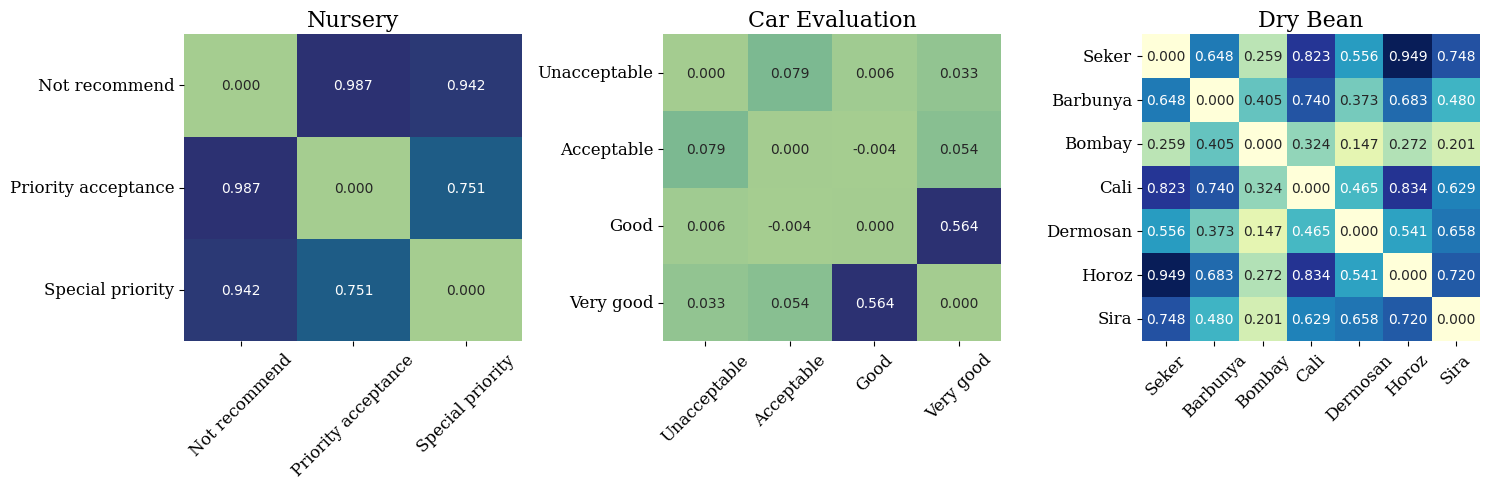

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define the data for the first heatmap
data = pd.DataFrame({
    1: [0.000000, 0.986786, 0.941856],
    2: [0.986786, 0.000000, 0.750744],
    3: [0.941856, 0.750744, 0.000000]
}, index=[1, 2, 3])

data2 = pd.DataFrame({
    0: [0.000000, 0.078952, 0.006451, 0.033488],
    1: [0.078952, 0.000000, -0.004232, 0.053968],
    2: [0.006451, -0.004232, 0.000000, 0.563759],
    3: [0.033488, 0.053968, 0.563759, 0.000000]
}, index=[0, 1, 2, 3])

data3 = pd.DataFrame({
    0: [0.000000, 0.647969, 0.259081, 0.823194, 0.556445, 0.948990, 0.748387],
    1: [0.647969, 0.000000, 0.405124, 0.740146, 0.373423, 0.683445, 0.480387],
    2: [0.259081, 0.405124, 0.000000, 0.324190, 0.147304, 0.272212, 0.200758],
    3: [0.823194, 0.740146, 0.324190, 0.000000, 0.465080, 0.833952, 0.628691],
    4: [0.556445, 0.373423, 0.147304, 0.465080, 0.000000, 0.541103, 0.657704],
    5: [0.948990, 0.683445, 0.272212, 0.833952, 0.541103, 0.000000, 0.719682],
    6: [0.748387, 0.480387, 0.200758, 0.628691, 0.657704, 0.719682, 0.000000]
}, index=[0, 1, 2, 3, 4, 5, 6])

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
x_font = {'family': 'serif', 'size': 12}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Define the font size
font_size = 10  # Increased by 3 for larger text

# First heatmap (Nursery) with 3 decimal places and larger text
sns.heatmap(data, ax=ax[0], annot=True, cmap="crest", cbar=False, fmt=".3f", annot_kws={"size": font_size})
ax[0].set_title("Nursery", fontdict=font)
ax[0].set_xticklabels(['Not recommend', 'Priority acceptance', 'Special priority'], rotation=45, fontdict=x_font)
ax[0].set_yticklabels(['Not recommend', 'Priority acceptance', 'Special priority'], rotation=0, fontdict=x_font)

# Second heatmap (Car) with 3 decimal places and larger text
sns.heatmap(data2, ax=ax[1], annot=True, cmap="crest", cbar=False, fmt=".3f", annot_kws={"size": font_size})
ax[1].set_title("Car Evaluation", fontdict=font)
ax[1].set_xticklabels(['Unacceptable', 'Acceptable', 'Good', 'Very good'], rotation=45, fontdict=x_font)
ax[1].set_yticklabels(['Unacceptable', 'Acceptable', 'Good', 'Very good'], rotation=0, fontdict=x_font)

# Third heatmap (Dry Bean) with 3 decimal places and larger text
sns.heatmap(data3, ax=ax[2], annot=True, cmap="YlGnBu", cbar=False, fmt=".3f", annot_kws={"size": font_size})
ax[2].set_title("Dry Bean", fontdict=font)
ax[2].set_xticklabels(['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira'], rotation=45, fontdict=x_font)
ax[2].set_yticklabels(['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira'], rotation=0, fontdict=x_font)

# Show the plot
plt.tight_layout()
plt.show()

# XGboost

In [ ]:
import numpy as np
from xgboost import XGBClassifier
nursery.target = nursery.target - 1
# Set the different random seeds you want to use
random_seeds = [42, 43, 44]

# Lists to store the results from each run
imv_matrices_results = []
imv_ova_results = []

# Run the analysis for each seed
for seed in random_seeds:
    imv_analyzer = MultinomialIMV(
        data=nursery,
        outcome_variable='target',  # Name of the outcome variable
        model_creator=lambda: XGBClassifier(random_state=seed, use_label_encoder=False, eval_metric='mlogloss'),
        n_splits=10,  # Number of splits for k-fold cross-validation
        optional_explanatory_variables=['parents', 'has_nurs', 'form', 'children', 'housing', 'finance', 'social', 'health'],  # List of feature names, if not all columns
        random_state=seed  # The random seed
    )

    # Perform the IMV calculations
    ova_results, ova_average = imv_analyzer.k_fold_one_vs_all()
    matrix_results, matrix_average = imv_analyzer.k_fold_imv_matrix()

    imv_matrices_results.append(matrix_average.values)
    imv_ova_results.append(ova_average)

# Calculate the mean and variance across the results from the different seeds
mean_imv_matrix = np.mean(imv_matrices_results, axis=0)
variance_imv_matrix = np.var(imv_matrices_results, axis=0)

mean_ova = np.mean(imv_ova_results, axis=0)
variance_ova = np.var(imv_ova_results, axis=0)

# Convert the mean and variance results into DataFrames for better visualization
mean_imv_matrix_df = pd.DataFrame(mean_imv_matrix, index=nursery['target'].unique(), columns=nursery['target'].unique())
variance_imv_matrix_df = pd.DataFrame(variance_imv_matrix, index=nursery['target'].unique(), columns=nursery['target'].unique())
outcomes = [1, 2, 3]
mean_imv_matrix_df = pd.DataFrame(mean_imv_matrix, index=outcomes, columns=outcomes)

mean_ova_df = pd.DataFrame({'class': nursery['target'].unique(), 'mean_imv': mean_ova, 'variance_imv': variance_ova})


# Display the results
print("Mean IMV Matrix:")
print(mean_imv_matrix_df)

print("\nVariance IMV Matrix:")
print(variance_imv_matrix_df)

print("\nOne-vs-All IMV Mean and Variance:")
print(mean_ova_df)

[array([0.55863188, 0.53020846, 0.42181819]), array([0.541542  , 0.50214178, 0.45563129]), array([0.48322108, 0.4969656 , 0.52311874]), array([0.48787525, 0.48699509, 0.52986645]), array([0.57486375, 0.4969656 , 0.43728621]), array([0.55863188, 0.50389702, 0.44171957]), array([0.5147142 , 0.52821214, 0.45563129]), array([0.50252816, 0.48061252, 0.51873792]), array([0.516517  , 0.53839434, 0.44625205]), array([0.47276845, 0.5302084 , 0.50008523])]
          0         1         2
0  0.000000  0.985294  0.936350
1  0.985294  0.000000  0.945158
2  0.936351  0.945158  0.000000
[array([0.50422428, 0.50389702, 0.48851545]), array([0.56087267, 0.49026409, 0.45245676]), array([0.49588281, 0.48699509, 0.51873792]), array([0.5129274 , 0.52427701, 0.46048738]), array([0.51115646, 0.51662791, 0.46884494]), array([0.51115646, 0.49696554, 0.48851545]), array([0.55863171, 0.49358704, 0.45088776]), array([0.47718061, 0.55581996, 0.47228516]), array([0.53154788, 0.5302084 , 0.44023107]), array([0.535486

In [ ]:
import numpy as np

# New data for the three seeds, each with 3 outcomes
new_seed_42_results = [
    np.array([0.55863188, 0.53020846, 0.42181819]),
    np.array([0.541542  , 0.50214178, 0.45563129]),
    np.array([0.48322108, 0.4969656 , 0.52311874]),
    np.array([0.48787525, 0.48699509, 0.52986645]),
    np.array([0.57486375, 0.4969656 , 0.43728621]),
    np.array([0.55863188, 0.50389702, 0.44171957]),
    np.array([0.5147142 , 0.52821214, 0.45563129]),
    np.array([0.50252816, 0.48061252, 0.51873792]),
    np.array([0.516517  , 0.53839434, 0.44625205]),
    np.array([0.47276845, 0.5302084 , 0.50008523])
]

new_seed_43_results = [
    np.array([0.50422428, 0.50389702, 0.48851545]),
    np.array([0.56087267, 0.49026409, 0.45245676]),
    np.array([0.49588281, 0.48699509, 0.51873792]),
    np.array([0.5129274 , 0.52427701, 0.46048738]),
    np.array([0.51115646, 0.51662791, 0.46884494]),
    np.array([0.51115646, 0.49696554, 0.48851545]),
    np.array([0.55863171, 0.49358704, 0.45088776]),
    np.array([0.47718061, 0.55581996, 0.47228516]),
    np.array([0.53154788, 0.5302084 , 0.44023107]),
    np.array([0.53548659, 0.49696554, 0.46546108])
]

new_seed_44_results = [
    np.array([0.51471427, 0.53631705, 0.4493308 ]),
    np.array([0.50422428, 0.59313448, 0.42317598]),
    np.array([0.56087267, 0.51290849, 0.43294813]),
    np.array([0.50252785, 0.51662791, 0.47755524]),
    np.array([0.51471427, 0.51851348, 0.46378979]),
    np.array([0.53154788, 0.50214172, 0.46378979]),
    np.array([0.49425539, 0.48061264, 0.52986645]),
    np.array([0.57975051, 0.44610336, 0.49039969]),
    np.array([0.51471427, 0.46260528, 0.52986645]),
    np.array([0.48476033, 0.55810619, 0.46213186])
]

# Calculating the mean for each outcome for each seed
new_mean_42 = np.mean(new_seed_42_results, axis=0)
new_mean_43 = np.mean(new_seed_43_results, axis=0)
new_mean_44 = np.mean(new_seed_44_results, axis=0)

# Calculating the overall mean and variance for each outcome across the three seeds
new_overall_mean = np.mean([new_mean_42, new_mean_43, new_mean_44], axis=0)
new_overall_variance = np.var([new_mean_42, new_mean_43, new_mean_44], axis=0)

new_mean_42, new_mean_43, new_mean_44, new_overall_mean, new_overall_variance


(array([0.52112936, 0.5094601 , 0.47301469]),
 array([0.51990669, 0.50956076, 0.4706423 ]),
 array([0.52020817, 0.51270706, 0.47228542]),
 array([0.52041474, 0.51057597, 0.4719808 ]),
 array([2.70492360e-07, 2.27245765e-06, 9.84439737e-07]))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, jaccard_score, brier_score_loss,
                             classification_report, cohen_kappa_score, hamming_loss)
from sklearn.metrics import r2_score
from xgboost import XGBClassifier

#nursery.target = nursery.target - 1
X = nursery[['parents', 'has_nurs', 'form', 'children', 'housing', 'finance', 'social', 'health']]
y = nursery['target']


seeds = [42, 43, 44]


results = []


for seed in seeds:

    model = XGBClassifier(random_state=seed, use_label_encoder=False, eval_metric='mlogloss')

    kf = KFold(n_splits=10, shuffle=True, random_state=seed)
    y_pred = cross_val_predict(model, X, y, cv=kf)
    y_prob = cross_val_predict(model, X, y, cv=kf, method='predict_proba')


    report = classification_report(y, y_pred, output_dict=True)

    r2 = r2_score(y, model.fit(X, y).predict(X))

    brier_scores = {}
    for i, label in enumerate(np.unique(y)):
        brier_scores[str(label)] = brier_score_loss(y == label, y_prob[:, i])


    f1 = f1_score(y, y_pred, average='weighted')
    auc_roc = roc_auc_score(y, y_prob, multi_class='ovr')
    log_loss_value = log_loss(y, y_prob)
    jaccard = jaccard_score(y, y_pred, average='weighted')


    kappa = cohen_kappa_score(y, y_pred)


    hamming = hamming_loss(y, y_pred)


    results.append({
        'seed': seed,
        'accuracy_per_class': {label: report[label]['precision'] for label in report if label.isdigit()},
        'precision_per_class': {label: report[label]['precision'] for label in report if label.isdigit()},
        'recall_per_class': {label: report[label]['recall'] for label in report if label.isdigit()},
        'support_per_class': {label: report[label]['support'] for label in report if label.isdigit()},
        'brier_score_per_class': brier_scores,
        'r_squared': r2,
        'f1_score': f1,
        'auc_roc': auc_roc,
        'log_loss': log_loss_value,
        'jaccard': jaccard,
        'kappa': kappa,
        'hamming_loss': hamming
    })

average_results = {
    'accuracy_mean': {},
    'accuracy_std': {},
    'precision_mean': {},
    'precision_std': {},
    'recall_mean': {},
    'recall_std': {},
    'support_mean': {},
    'support_std': {},
    'brier_score_mean': {},
    'brier_score_std': {},
    'r_squared_mean': np.mean([result['r_squared'] for result in results]),
    'r_squared_std': np.std([result['r_squared'] for result in results]),
    'f1_score_mean': np.mean([result['f1_score'] for result in results]),
    'f1_score_std': np.std([result['f1_score'] for result in results]),
    'auc_roc_mean': np.mean([result['auc_roc'] for result in results]),
    'auc_roc_std': np.std([result['auc_roc'] for result in results]),
    'log_loss_mean': np.mean([result['log_loss'] for result in results]),
    'log_loss_std': np.std([result['log_loss'] for result in results]),
    'jaccard_mean': np.mean([result['jaccard'] for result in results]),
    'jaccard_std': np.std([result['jaccard'] for result in results]),
    'kappa_mean': np.mean([result['kappa'] for result in results]),
    'kappa_std': np.std([result['kappa'] for result in results]),
    'hamming_loss_mean': np.mean([result['hamming_loss'] for result in results]),
    'hamming_loss_std': np.std([result['hamming_loss'] for result in results])
}

for label in results[0]['accuracy_per_class'].keys():
    accuracy_values = [result['accuracy_per_class'][label] for result in results]
    average_results['accuracy_mean'][label] = np.mean(accuracy_values)
    average_results['accuracy_std'][label] = np.std(accuracy_values)

    precision_values = [result['precision_per_class'][label] for result in results]
    average_results['precision_mean'][label] = np.mean(precision_values)
    average_results['precision_std'][label] = np.std(precision_values)

    recall_values = [result['recall_per_class'][label] for result in results]
    average_results['recall_mean'][label] = np.mean(recall_values)
    average_results['recall_std'][label] = np.std(recall_values)

    support_values = [result['support_per_class'][label] for result in results]
    average_results['support_mean'][label] = np.mean(support_values)
    average_results['support_std'][label] = np.std(support_values)

    brier_values = [result['brier_score_per_class'][label] for result in results]
    average_results['brier_score_mean'][label] = np.mean(brier_values)
    average_results['brier_score_std'][label] = np.std(brier_values)

print("Mean and Standard Deviation for each metric across seeds:")
for label in average_results['accuracy_mean'].keys():
    print(f"Class {label}:")
    print(f"  Accuracy Mean: {average_results['accuracy_mean'][label]:.4f}, Std: {average_results['accuracy_std'][label]:.4f}")
    print(f"  Precision Mean: {average_results['precision_mean'][label]:.4f}, Std: {average_results['precision_std'][label]:.4f}")
    print(f"  Recall Mean: {average_results['recall_mean'][label]:.4f}, Std: {average_results['recall_std'][label]:.4f}")
    print(f"  Support Mean: {average_results['support_mean'][label]:.4f}, Std: {average_results['support_std'][label]:.4f}")
    print(f"  Brier Score Mean: {average_results['brier_score_mean'][label]:.4f}, Std: {average_results['brier_score_std'][label]:.4f}")

print(f"Overall R^2 Mean: {average_results['r_squared_mean']:.4f}, Std: {average_results['r_squared_std']:.4f}")
print(f"Overall F1 Score Mean: {average_results['f1_score_mean']:.4f}, Std: {average_results['f1_score_std']:.4f}")
print(f"Overall AUC-ROC Mean: {average_results['auc_roc_mean']:.4f}, Std: {average_results['auc_roc_std']:.4f}")
print(f"Overall Log Loss Mean: {average_results['log_loss_mean']:.4f}, Std: {average_results['log_loss_std']:.4f}")
print(f"Overall Jaccard Mean: {average_results['jaccard_mean']:.4f}, Std: {average_results['jaccard_std']:.4f}")
print(f"Overall Cohen's Kappa Mean: {average_results['kappa_mean']:.4f}, Std: {average_results['kappa_std']:.4f}")
print(f"Overall Hamming Loss Mean: {average_results['hamming_loss_mean']:.4f}, Std: {average_results['hamming_loss_std']:.4f}")

Mean and Standard Deviation for each metric across seeds:
Class 0:
  Accuracy Mean: 1.0000, Std: 0.0000
  Precision Mean: 1.0000, Std: 0.0000
  Recall Mean: 1.0000, Std: 0.0000
  Support Mean: 4320.0000, Std: 0.0000
  Brier Score Mean: 0.0000, Std: 0.0000
Class 1:
  Accuracy Mean: 1.0000, Std: 0.0000
  Precision Mean: 1.0000, Std: 0.0000
  Recall Mean: 1.0000, Std: 0.0000
  Support Mean: 4266.0000, Std: 0.0000
  Brier Score Mean: 0.0000, Std: 0.0000
Class 2:
  Accuracy Mean: 1.0000, Std: 0.0000
  Precision Mean: 1.0000, Std: 0.0000
  Recall Mean: 1.0000, Std: 0.0000
  Support Mean: 4044.0000, Std: 0.0000
  Brier Score Mean: 0.0000, Std: 0.0000
Overall R^2 Mean: 1.0000, Std: 0.0000
Overall F1 Score Mean: 1.0000, Std: 0.0000
Overall AUC-ROC Mean: 1.0000, Std: 0.0000
Overall Log Loss Mean: 0.0013, Std: 0.0000
Overall Jaccard Mean: 1.0000, Std: 0.0000
Overall Cohen's Kappa Mean: 1.0000, Std: 0.0000
Overall Hamming Loss Mean: 0.0000, Std: 0.0000


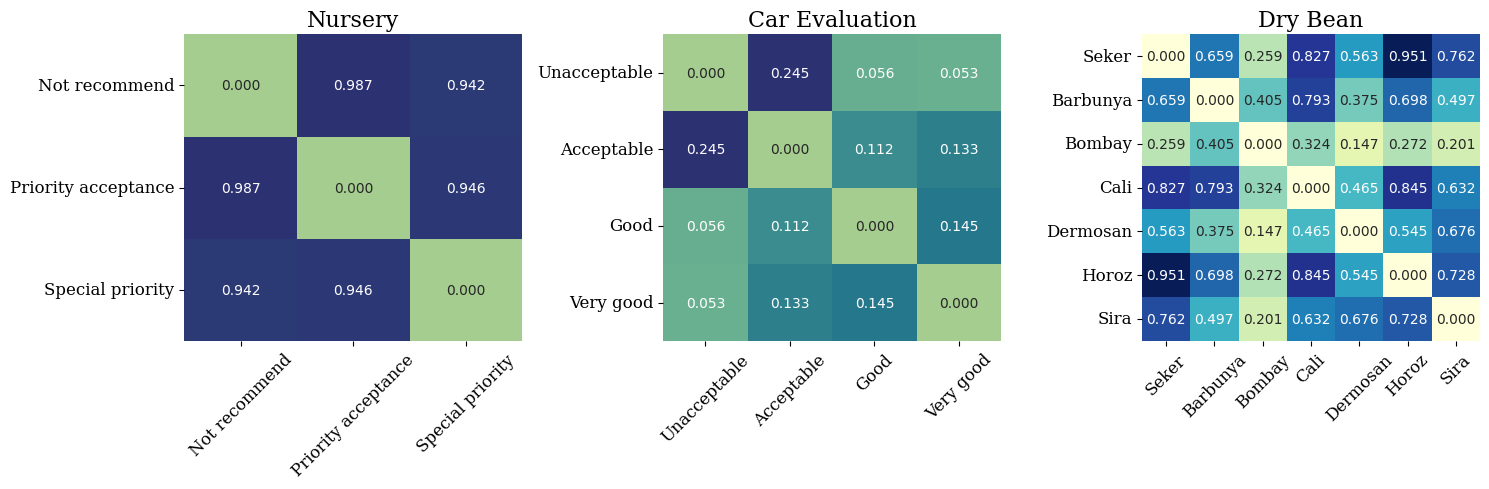

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define the data for the first heatmap
data = pd.DataFrame({
    1: [0.000000, 0.986785, 0.941855],
    2: [0.986785, 0.000000, 0.946480],
    3: [0.941855, 0.946480, 0.000000]
}, index=[1, 2, 3])

data2 = pd.DataFrame({
    0: [0.000000, 0.245256, 0.055559, 0.052893],
    1: [0.245256, 0.000000, 0.111840, 0.132506],
    2: [0.055559, 0.111840, 0.000000, 0.144586],
    3: [0.052893, 0.132506, 0.144586, 0.000000]
}, index=[0, 1, 2, 3])

data3 = pd.DataFrame({
    0: [0.000000, 0.659436, 0.259084, 0.827183, 0.563337, 0.951199, 0.762337],
    1: [0.659436, 0.000000, 0.405077, 0.792800, 0.374851, 0.697894, 0.497266],
    2: [0.259084, 0.405077, 0.000000, 0.323538, 0.147306, 0.272183, 0.200762],
    3: [0.827183, 0.792800, 0.323538, 0.000000, 0.465257, 0.844695, 0.632098],
    4: [0.563337, 0.374851, 0.147306, 0.465257, 0.000000, 0.544957, 0.675587],
    5: [0.951199, 0.697894, 0.272183, 0.844695, 0.544957, 0.000000, 0.728311],
    6: [0.762337, 0.497266, 0.200762, 0.632098, 0.675587, 0.728311, 0.000000]
}, index=[0, 1, 2, 3, 4, 5, 6])

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
x_font = {'family': 'serif', 'size': 12}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Define the font size
font_size = 10  # Increased by 3 for larger text

# First heatmap (Nursery) with 3 decimal places and larger text
sns.heatmap(data, ax=ax[0], annot=True, cmap="crest", cbar=False, fmt=".3f", annot_kws={"size": font_size})
ax[0].set_title("Nursery", fontdict=font)
ax[0].set_xticklabels(['Not recommend', 'Priority acceptance', 'Special priority'], rotation=45, fontdict=x_font)
ax[0].set_yticklabels(['Not recommend', 'Priority acceptance', 'Special priority'], rotation=0, fontdict=x_font)

# Second heatmap (Car) with 3 decimal places and larger text
sns.heatmap(data2, ax=ax[1], annot=True, cmap="crest", cbar=False, fmt=".3f", annot_kws={"size": font_size})
ax[1].set_title("Car Evaluation", fontdict=font)
ax[1].set_xticklabels(['Unacceptable', 'Acceptable', 'Good', 'Very good'], rotation=45, fontdict=x_font)
ax[1].set_yticklabels(['Unacceptable', 'Acceptable', 'Good', 'Very good'], rotation=0, fontdict=x_font)

# Third heatmap (Dry Bean) with 3 decimal places and larger text
sns.heatmap(data3, ax=ax[2], annot=True, cmap="YlGnBu", cbar=False, fmt=".3f", annot_kws={"size": font_size})
ax[2].set_title("Dry Bean", fontdict=font)
ax[2].set_xticklabels(['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira'], rotation=45, fontdict=x_font)
ax[2].set_yticklabels(['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira'], rotation=0, fontdict=x_font)

# Show the plot
plt.tight_layout()
plt.show()

# LightGBM

In [ ]:
import numpy as np
from lightgbm import LGBMClassifier
nursery.target = nursery.target - 1
# Set the different random seeds you want to use
random_seeds = [42, 43, 44]

# Lists to store the results from each run
imv_matrices_results = []
imv_ova_results = []

# Run the analysis for each seed
for seed in random_seeds:
    imv_analyzer = MultinomialIMV(
        data=nursery,
        outcome_variable='target',  # Name of the outcome variable
        model_creator=lambda: LGBMClassifier(random_state=seed, n_estimators=100, verbose=-1),
        n_splits=10,  # Number of splits for k-fold cross-validation
        optional_explanatory_variables=['parents', 'has_nurs', 'form', 'children', 'housing', 'finance', 'social', 'health'],  # List of feature names, if not all columns
        random_state=seed  # The random seed
    )

    # Perform the IMV calculations
    ova_results, ova_average = imv_analyzer.k_fold_one_vs_all()
    matrix_results, matrix_average = imv_analyzer.k_fold_imv_matrix()

    imv_matrices_results.append(matrix_average.values)
    imv_ova_results.append(ova_average)

# Calculate the mean and variance across the results from the different seeds
mean_imv_matrix = np.mean(imv_matrices_results, axis=0)
variance_imv_matrix = np.var(imv_matrices_results, axis=0)

mean_ova = np.mean(imv_ova_results, axis=0)
variance_ova = np.var(imv_ova_results, axis=0)

# Convert the mean and variance results into DataFrames for better visualization
mean_imv_matrix_df = pd.DataFrame(mean_imv_matrix, index=nursery['target'].unique(), columns=nursery['target'].unique())
variance_imv_matrix_df = pd.DataFrame(variance_imv_matrix, index=nursery['target'].unique(), columns=nursery['target'].unique())
outcomes = [1, 2, 3]
mean_imv_matrix_df = pd.DataFrame(mean_imv_matrix, index=outcomes, columns=outcomes)

mean_ova_df = pd.DataFrame({'class': nursery['target'].unique(), 'mean_imv': mean_ova, 'variance_imv': variance_ova})


# Display the results
print("Mean IMV Matrix:")
print(mean_imv_matrix_df)

print("\nVariance IMV Matrix:")
print(variance_imv_matrix_df)

print("\nOne-vs-All IMV Mean and Variance:")
print(mean_ova_df)

[array([0.55863177, 0.53020829, 0.42181819]), array([0.54154194, 0.50214176, 0.45563125]), array([0.48322104, 0.49696557, 0.52311869]), array([0.48787534, 0.48699513, 0.52986644]), array([0.57486378, 0.49696557, 0.43728626]), array([0.55863177, 0.503897  , 0.44171955]), array([0.51471418, 0.52821203, 0.45563125]), array([0.50252804, 0.48061262, 0.51873792]), array([0.51651684, 0.53839428, 0.44625199]), array([0.47276836, 0.53020829, 0.50008525])]
          -2        -1         0
-2  0.000000  0.985294  0.936350
-1  0.985294  0.000000  0.945157
 0  0.936350  0.945157  0.000000
[array([0.50422435, 0.503897  , 0.48851548]), array([0.56087272, 0.49026409, 0.4524567 ]), array([0.49588278, 0.48699513, 0.51873792]), array([0.51292748, 0.5242771 , 0.4604873 ]), array([0.5111565 , 0.51662792, 0.46884482]), array([0.5111565 , 0.49696557, 0.48851548]), array([0.55863177, 0.493587  , 0.45088773]), array([0.47718053, 0.55581991, 0.47228509]), array([0.53154786, 0.53020829, 0.44023097]), array([0.53

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, jaccard_score, brier_score_loss,
                             classification_report, cohen_kappa_score, hamming_loss)
from sklearn.metrics import r2_score
from lightgbm import LGBMClassifier

#nursery.target = nursery.target - 1
X = nursery[['parents', 'has_nurs', 'form', 'children', 'housing', 'finance', 'social', 'health']]
y = nursery['target']


seeds = [42, 43, 44]


results = []


for seed in seeds:

    model = LGBMClassifier(random_state=seed, n_estimators=100, verbose=-1)

    kf = KFold(n_splits=10, shuffle=True, random_state=seed)
    y_pred = cross_val_predict(model, X, y, cv=kf)
    y_prob = cross_val_predict(model, X, y, cv=kf, method='predict_proba')


    report = classification_report(y, y_pred, output_dict=True)

    r2 = r2_score(y, model.fit(X, y).predict(X))

    brier_scores = {}
    for i, label in enumerate(np.unique(y)):
        brier_scores[str(label)] = brier_score_loss(y == label, y_prob[:, i])


    f1 = f1_score(y, y_pred, average='weighted')
    auc_roc = roc_auc_score(y, y_prob, multi_class='ovr')
    log_loss_value = log_loss(y, y_prob)
    jaccard = jaccard_score(y, y_pred, average='weighted')


    kappa = cohen_kappa_score(y, y_pred)


    hamming = hamming_loss(y, y_pred)


    results.append({
        'seed': seed,
        'accuracy_per_class': {label: report[label]['precision'] for label in report if label.isdigit()},
        'precision_per_class': {label: report[label]['precision'] for label in report if label.isdigit()},
        'recall_per_class': {label: report[label]['recall'] for label in report if label.isdigit()},
        'support_per_class': {label: report[label]['support'] for label in report if label.isdigit()},
        'brier_score_per_class': brier_scores,
        'r_squared': r2,
        'f1_score': f1,
        'auc_roc': auc_roc,
        'log_loss': log_loss_value,
        'jaccard': jaccard,
        'kappa': kappa,
        'hamming_loss': hamming
    })

average_results = {
    'accuracy_mean': {},
    'accuracy_std': {},
    'precision_mean': {},
    'precision_std': {},
    'recall_mean': {},
    'recall_std': {},
    'support_mean': {},
    'support_std': {},
    'brier_score_mean': {},
    'brier_score_std': {},
    'r_squared_mean': np.mean([result['r_squared'] for result in results]),
    'r_squared_std': np.std([result['r_squared'] for result in results]),
    'f1_score_mean': np.mean([result['f1_score'] for result in results]),
    'f1_score_std': np.std([result['f1_score'] for result in results]),
    'auc_roc_mean': np.mean([result['auc_roc'] for result in results]),
    'auc_roc_std': np.std([result['auc_roc'] for result in results]),
    'log_loss_mean': np.mean([result['log_loss'] for result in results]),
    'log_loss_std': np.std([result['log_loss'] for result in results]),
    'jaccard_mean': np.mean([result['jaccard'] for result in results]),
    'jaccard_std': np.std([result['jaccard'] for result in results]),
    'kappa_mean': np.mean([result['kappa'] for result in results]),
    'kappa_std': np.std([result['kappa'] for result in results]),
    'hamming_loss_mean': np.mean([result['hamming_loss'] for result in results]),
    'hamming_loss_std': np.std([result['hamming_loss'] for result in results])
}

for label in results[0]['accuracy_per_class'].keys():
    accuracy_values = [result['accuracy_per_class'][label] for result in results]
    average_results['accuracy_mean'][label] = np.mean(accuracy_values)
    average_results['accuracy_std'][label] = np.std(accuracy_values)

    precision_values = [result['precision_per_class'][label] for result in results]
    average_results['precision_mean'][label] = np.mean(precision_values)
    average_results['precision_std'][label] = np.std(precision_values)

    recall_values = [result['recall_per_class'][label] for result in results]
    average_results['recall_mean'][label] = np.mean(recall_values)
    average_results['recall_std'][label] = np.std(recall_values)

    support_values = [result['support_per_class'][label] for result in results]
    average_results['support_mean'][label] = np.mean(support_values)
    average_results['support_std'][label] = np.std(support_values)

    brier_values = [result['brier_score_per_class'][label] for result in results]
    average_results['brier_score_mean'][label] = np.mean(brier_values)
    average_results['brier_score_std'][label] = np.std(brier_values)

print("Mean and Standard Deviation for each metric across seeds:")
for label in average_results['accuracy_mean'].keys():
    print(f"Class {label}:")
    print(f"  Accuracy Mean: {average_results['accuracy_mean'][label]:.4f}, Std: {average_results['accuracy_std'][label]:.4f}")
    print(f"  Precision Mean: {average_results['precision_mean'][label]:.4f}, Std: {average_results['precision_std'][label]:.4f}")
    print(f"  Recall Mean: {average_results['recall_mean'][label]:.4f}, Std: {average_results['recall_std'][label]:.4f}")
    print(f"  Support Mean: {average_results['support_mean'][label]:.4f}, Std: {average_results['support_std'][label]:.4f}")
    print(f"  Brier Score Mean: {average_results['brier_score_mean'][label]:.4f}, Std: {average_results['brier_score_std'][label]:.4f}")

print(f"Overall R^2 Mean: {average_results['r_squared_mean']:.4f}, Std: {average_results['r_squared_std']:.4f}")
print(f"Overall F1 Score Mean: {average_results['f1_score_mean']:.4f}, Std: {average_results['f1_score_std']:.4f}")
print(f"Overall AUC-ROC Mean: {average_results['auc_roc_mean']:.4f}, Std: {average_results['auc_roc_std']:.4f}")
print(f"Overall Log Loss Mean: {average_results['log_loss_mean']:.4f}, Std: {average_results['log_loss_std']:.4f}")
print(f"Overall Jaccard Mean: {average_results['jaccard_mean']:.4f}, Std: {average_results['jaccard_std']:.4f}")
print(f"Overall Cohen's Kappa Mean: {average_results['kappa_mean']:.4f}, Std: {average_results['kappa_std']:.4f}")
print(f"Overall Hamming Loss Mean: {average_results['hamming_loss_mean']:.4f}, Std: {average_results['hamming_loss_std']:.4f}")

Mean and Standard Deviation for each metric across seeds:
Class 0:
  Accuracy Mean: 1.0000, Std: 0.0000
  Precision Mean: 1.0000, Std: 0.0000
  Recall Mean: 1.0000, Std: 0.0000
  Support Mean: 4320.0000, Std: 0.0000
  Brier Score Mean: 0.0000, Std: 0.0000
Class 1:
  Accuracy Mean: 1.0000, Std: 0.0000
  Precision Mean: 1.0000, Std: 0.0000
  Recall Mean: 1.0000, Std: 0.0000
  Support Mean: 4266.0000, Std: 0.0000
  Brier Score Mean: 0.0001, Std: 0.0000
Class 2:
  Accuracy Mean: 1.0000, Std: 0.0000
  Precision Mean: 1.0000, Std: 0.0000
  Recall Mean: 1.0000, Std: 0.0000
  Support Mean: 4044.0000, Std: 0.0000
  Brier Score Mean: 0.0001, Std: 0.0000
Overall R^2 Mean: 1.0000, Std: 0.0000
Overall F1 Score Mean: 1.0000, Std: 0.0000
Overall AUC-ROC Mean: 1.0000, Std: 0.0000
Overall Log Loss Mean: 0.0024, Std: 0.0000
Overall Jaccard Mean: 1.0000, Std: 0.0000
Overall Cohen's Kappa Mean: 1.0000, Std: 0.0000
Overall Hamming Loss Mean: 0.0000, Std: 0.0000


In [ ]:
import numpy as np

# New data for the three seeds with 3 outcomes
new_seed_42_results = [
    np.array([0.55863177, 0.53020829, 0.42181819]),
    np.array([0.54154194, 0.50214176, 0.45563125]),
    np.array([0.48322104, 0.49696557, 0.52311869]),
    np.array([0.48787534, 0.48699513, 0.52986644]),
    np.array([0.57486378, 0.49696557, 0.43728626]),
    np.array([0.55863177, 0.503897  , 0.44171955]),
    np.array([0.51471418, 0.52821203, 0.45563125]),
    np.array([0.50252804, 0.48061262, 0.51873792]),
    np.array([0.51651684, 0.53839428, 0.44625199]),
    np.array([0.47276836, 0.53020829, 0.50008525])
]

new_seed_43_results = [
    np.array([0.50422435, 0.503897  , 0.48851548]),
    np.array([0.56087272, 0.49026409, 0.4524567 ]),
    np.array([0.49588278, 0.48699513, 0.51873792]),
    np.array([0.51292748, 0.5242771 , 0.4604873 ]),
    np.array([0.5111565 , 0.51662792, 0.46884482]),
    np.array([0.5111565 , 0.49696557, 0.48851548]),
    np.array([0.55863177, 0.493587  , 0.45088773]),
    np.array([0.47718053, 0.55581991, 0.47228509]),
    np.array([0.53154786, 0.53020829, 0.44023097]),
    np.array([0.53548662, 0.49696557, 0.46546098])
]

new_seed_44_results = [
    np.array([0.51471418, 0.53631684, 0.44933074]),
    np.array([0.50422435, 0.59313466, 0.42317603]),
    np.array([0.56087272, 0.51290842, 0.43294818]),
    np.array([0.50252804, 0.51662792, 0.47755529]),
    np.array([0.51471418, 0.51851347, 0.46378969]),
    np.array([0.53154786, 0.50214176, 0.46378969]),
    np.array([0.49425538, 0.48061262, 0.52986644]),
    np.array([0.57975036, 0.44610329, 0.49039971]),
    np.array([0.51471418, 0.46260522, 0.52986644]),
    np.array([0.4847604 , 0.55810628, 0.46213186])
]

# Calculating the mean for each outcome for each seed
new_mean_42 = np.mean(new_seed_42_results, axis=0)
new_mean_43 = np.mean(new_seed_43_results, axis=0)
new_mean_44 = np.mean(new_seed_44_results, axis=0)

# Calculating the overall mean and variance for each outcome across the three seeds
new_overall_mean = np.mean([new_mean_42, new_mean_43, new_mean_44], axis=0)
new_overall_variance = np.var([new_mean_42, new_mean_43, new_mean_44], axis=0)

new_mean_42, new_mean_43, new_mean_44, new_overall_mean, new_overall_variance

(array([0.52112931, 0.50946005, 0.47301468]),
 array([0.51990671, 0.50956076, 0.47064225]),
 array([0.52020817, 0.51270705, 0.47228541]),
 array([0.52041473, 0.51057595, 0.47198078]),
 array([2.70457088e-07, 2.27247246e-06, 9.84471781e-07]))

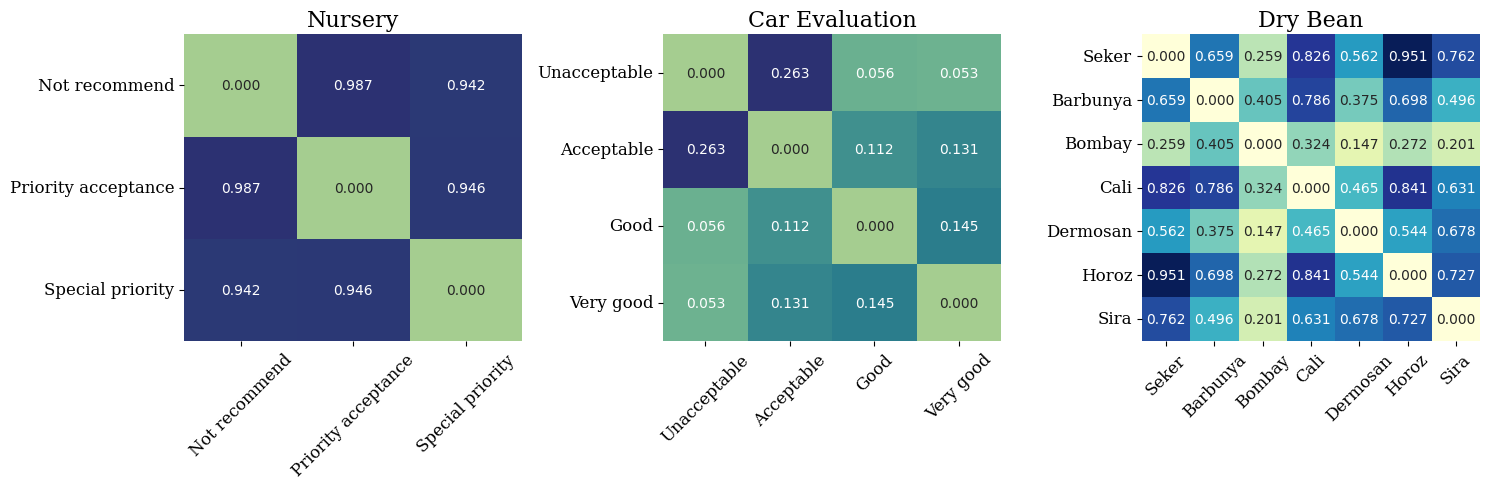

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define the data for the first heatmap
data = pd.DataFrame({
    1: [0.000000, 0.986784, 0.941855],
    2: [0.986784, 0.000000, 0.946480],
    3: [0.941855, 0.946480, 0.000000]
}, index=[1, 2, 3])


data2 = pd.DataFrame({
    0: [0.000000, 0.262659, 0.055662, 0.053025],
    1: [0.262659, 0.000000, 0.112241, 0.130989],
    2: [0.055662, 0.112241, 0.000000, 0.145380],
    3: [0.053025, 0.130989, 0.145380, 0.000000]
}, index=[0, 1, 2, 3])

data3 = pd.DataFrame({
    0: [0.000000, 0.658532, 0.259084, 0.826185, 0.561727, 0.951281, 0.761816],
    1: [0.658532, 0.000000, 0.404759, 0.786318, 0.374781, 0.697822, 0.496160],
    2: [0.259084, 0.404759, 0.000000, 0.323574, 0.147306, 0.272216, 0.200762],
    3: [0.826185, 0.786318, 0.323574, 0.000000, 0.465221, 0.840886, 0.630839],
    4: [0.561727, 0.374781, 0.147306, 0.465221, 0.000000, 0.544161, 0.678032],
    5: [0.951281, 0.697822, 0.272216, 0.840886, 0.544161, 0.000000, 0.726662],
    6: [0.761816, 0.496160, 0.200762, 0.630839, 0.678032, 0.726662, 0.000000]
}, index=[0, 1, 2, 3, 4, 5, 6])

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
x_font = {'family': 'serif', 'size': 12}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Define the font size
font_size = 10  # Increased by 3 for larger text

# First heatmap (Nursery) with 3 decimal places and larger text
sns.heatmap(data, ax=ax[0], annot=True, cmap="crest", cbar=False, fmt=".3f", annot_kws={"size": font_size})
ax[0].set_title("Nursery", fontdict=font)
ax[0].set_xticklabels(['Not recommend', 'Priority acceptance', 'Special priority'], rotation=45, fontdict=x_font)
ax[0].set_yticklabels(['Not recommend', 'Priority acceptance', 'Special priority'], rotation=0, fontdict=x_font)

# Second heatmap (Car) with 3 decimal places and larger text
sns.heatmap(data2, ax=ax[1], annot=True, cmap="crest", cbar=False, fmt=".3f", annot_kws={"size": font_size})
ax[1].set_title("Car Evaluation", fontdict=font)
ax[1].set_xticklabels(['Unacceptable', 'Acceptable', 'Good', 'Very good'], rotation=45, fontdict=x_font)
ax[1].set_yticklabels(['Unacceptable', 'Acceptable', 'Good', 'Very good'], rotation=0, fontdict=x_font)

# Third heatmap (Dry Bean) with 3 decimal places and larger text
sns.heatmap(data3, ax=ax[2], annot=True, cmap="YlGnBu", cbar=False, fmt=".3f", annot_kws={"size": font_size})
ax[2].set_title("Dry Bean", fontdict=font)
ax[2].set_xticklabels(['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira'], rotation=45, fontdict=x_font)
ax[2].set_yticklabels(['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira'], rotation=0, fontdict=x_font)

# Show the plot
plt.tight_layout()
plt.show()